<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 5 Day 2: DBSCAN & Hierarchical Clustering
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 2 Learning Objectives:</b>
-  <b>Overcoming K-Means Limitations:</b> Understand when spherical and outlier-sensitive assumptions fail in irregular or noisy data.
-  <b>Density-Based Clustering (DBSCAN):</b> Discover non-globular clusters and isolate noise points using neighborhood radius (`eps`) and minimum core density (`min_samples`).
-  <b>Hierarchical Clustering:</b> Build agglomerative cluster trees using Ward's minimum variance linkage, inspect dendrograms, and choose optimal cut heights.
-  <b>Comparative Evaluation:</b> Benchmark K-Means ($k=3$), DBSCAN, and Hierarchical clustering side-by-side using 2D scatter plots and silhouette scores.
-  <b>Algorithm Synthesis:</b> Connect dataset geometry to clustering assumptions and recommend the best-fitting method for the Palmer Penguins morphological dataset.

</blockquote>


## <span style="color: #39b64eff">2.1 Environment Setup & Library Imports</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import core numerical and visualization packages alongside Scikit-Learn modules for feature scaling, K-Means clustering, and silhouette evaluation.

</blockquote>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans

df = pd.read_csv('../../Data/raw/penguins_size.csv')


## <span style="color: #309c42ff">2.2 Dataset Loading & Feature Selection</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We load the Palmer Archipelago Penguins dataset (<code>penguins_size.csv</code>). Since this is an unsupervised task, we drop categorical identifiers and target labels, remove incomplete records with missing values, and isolate the continuous morphological features: <code>culmen_length_mm</code>, <code>culmen_depth_mm</code>, <code>flipper_length_mm</code>, and <code>body_mass_g</code> to construct the feature matrix $X$.

</blockquote>


In [2]:
df = df.dropna()

numeric_features = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[numeric_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## <span style="color: #39b64eff">2.3 Density-Based Spatial Clustering (DBSCAN)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

DBSCAN groups points that are packed closely together based on two parameters:
- <b>eps:</b> Maximum distance between two samples for one to be considered in the neighborhood of the other.
- <b>min_samples:</b> Number of samples in a neighborhood for a point to be considered a core point.

Points residing in low-density regions are explicitly flagged as noise (assigned label <code>-1</code>) rather than forced into clusters.

</blockquote>


In [3]:
db = DBSCAN(eps=0.8, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_db}")
print(f"Estimated number of noise points: {n_noise_db}")
print(f"Cluster label distribution:\n{pd.Series(db_labels).value_counts()}")

if n_clusters_db > 1:
    mask = db_labels != -1
    db_silhouette = silhouette_score(X_scaled[mask], db_labels[mask])
    print(f"DBSCAN Silhouette Score (excluding noise): {db_silhouette:.4f}")


Estimated number of clusters: 2
Estimated number of noise points: 5
Cluster label distribution:
 0    211
 1    118
-1      5
Name: count, dtype: int64
DBSCAN Silhouette Score (excluding noise): 0.5348


## <span style="color: #39b64eff">2.4 Hierarchical Clustering & Dendrogram Analysis</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Hierarchical clustering builds an agglomerative tree of clusters, iteratively merging the two closest clusters using Ward's minimum variance method. We visualize the nested structure through a <b>dendrogram</b> and determine an optimal cut height to extract cluster assignments.

</blockquote>


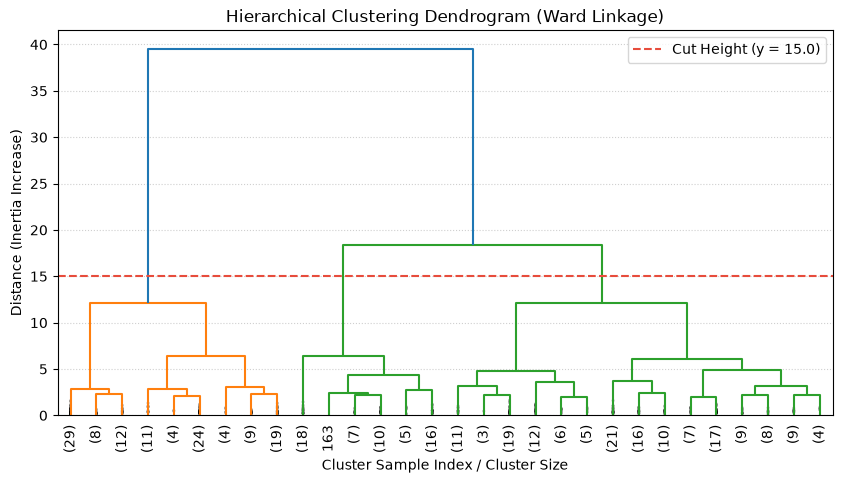

Number of clusters from cut height 15.0: 3
Hierarchical Clustering Silhouette Score: 0.4527


In [4]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
cut_height = 15.0
plt.axhline(y=cut_height, color='#E74C3C', linestyle='--', label=f'Cut Height (y = {cut_height})')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Sample Index / Cluster Size')
plt.ylabel('Distance (Inertia Increase)')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

hier_labels = fcluster(Z, t=cut_height, criterion='distance')
n_clusters_hier = len(np.unique(hier_labels))
hier_silhouette = silhouette_score(X_scaled, hier_labels)

print(f"Number of clusters from cut height {cut_height}: {n_clusters_hier}")
print(f"Hierarchical Clustering Silhouette Score: {hier_silhouette:.4f}")


## <span style="color: #39b64eff">2.5 Comparative Model Evaluation: K-Means vs. DBSCAN vs. Hierarchical</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We fit K-Means ($k=3$), DBSCAN ($\epsilon=0.8, \text{MinPts}=5$), and Hierarchical Clustering (Ward, $k=3$) on the identical standardized feature matrix. We plot 2D scatter comparisons across Culmen Length versus Flipper Length and benchmark their cluster counts, noise identification, and Silhouette Scores.

</blockquote>


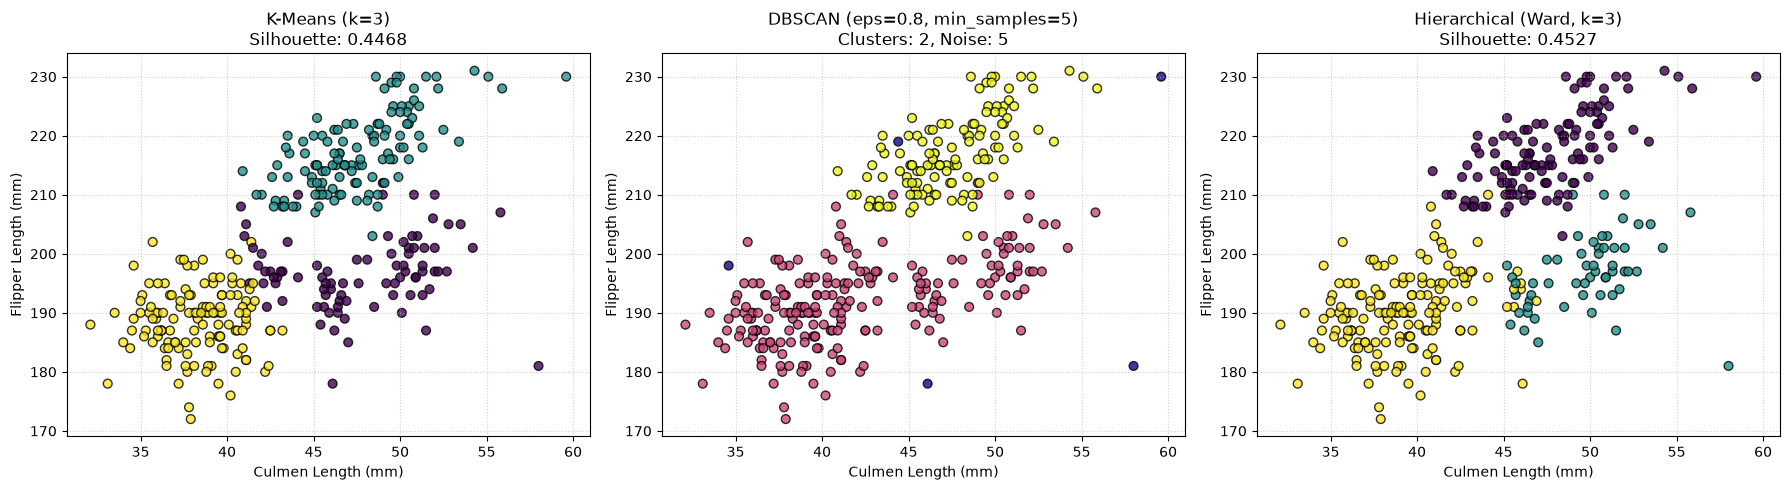

          Algorithm  Discovered Clusters  Noise Points Silhouette Score
            K-Means                    3             0           0.4468
             DBSCAN                    2             5           0.5348
Hierarchical (Ward)                    3             0           0.4527


In [5]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)
km_silhouette = silhouette_score(X_scaled, km_labels)

hier_labels_3 = fcluster(Z, t=3, criterion='maxclust')
hier_silhouette_3 = silhouette_score(X_scaled, hier_labels_3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X['culmen_length_mm'], X['flipper_length_mm'], c=km_labels, cmap='viridis', s=40, edgecolors='k', alpha=0.8)
axes[0].set_title(f"K-Means (k=3)\nSilhouette: {km_silhouette:.4f}")
axes[0].set_xlabel('Culmen Length (mm)')
axes[0].set_ylabel('Flipper Length (mm)')
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].scatter(X['culmen_length_mm'], X['flipper_length_mm'], c=db_labels, cmap='plasma', s=40, edgecolors='k', alpha=0.8)
axes[1].set_title(f"DBSCAN (eps=0.8, min_samples=5)\nClusters: {n_clusters_db}, Noise: {n_noise_db}")
axes[1].set_xlabel('Culmen Length (mm)')
axes[1].set_ylabel('Flipper Length (mm)')
axes[1].grid(True, linestyle=':', alpha=0.6)

axes[2].scatter(X['culmen_length_mm'], X['flipper_length_mm'], c=hier_labels_3, cmap='viridis', s=40, edgecolors='k', alpha=0.8)
axes[2].set_title(f"Hierarchical (Ward, k=3)\nSilhouette: {hier_silhouette_3:.4f}")
axes[2].set_xlabel('Culmen Length (mm)')
axes[2].set_ylabel('Flipper Length (mm)')
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'DBSCAN', 'Hierarchical (Ward)'],
    'Discovered Clusters': [3, n_clusters_db, 3],
    'Noise Points': [0, n_noise_db, 0],
    'Silhouette Score': [f"{km_silhouette:.4f}", f"{db_silhouette:.4f}", f"{hier_silhouette_3:.4f}"]
})
print(comparison_df.to_string(index=False))


## <span style="color: #9f43c3ff">2.6 Model Synthesis & Dataset Method Recommendation</span>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

### Comparative Evaluation Summary:
1. <b>K-Means:</b> Best when clusters are round and similarly sized, with $k$ roughly known. For the Palmer Penguins dataset, the continuous morphological measurements form compact, spherical groupings representing the biological species.
2. <b>DBSCAN:</b> Best for irregular shapes and datasets containing outliers. On continuous biometric measurements with uniform density across clusters, DBSCAN can struggle with density threshold sensitivity (`eps`), either merging adjacent clusters or labeling valid peripheral specimens as noise.
3. <b>Hierarchical Clustering:</b> Ward linkage minimizes within-cluster variance and yields a dendrogram that reflects natural biological sub-groupings.

### Final Method Recommendation:
For the Palmer Penguins morphological feature matrix, <b>K-Means (or Agglomerative Hierarchical with Ward Linkage) at $k=3$</b> is the most suitable method. The data forms distinct, globular clusters without irregular density ribbons, aligning directly with the distance-minimization assumptions of K-Means and Ward linkage.

</blockquote>
